# 01 — Uniformize and to_normal

Test the first two steps of the *echo* pipeline on a synthetic 3-variable sample.

- Step 1 — `fit_uniformize`: each variable → uniform on (0, 1) via the empirical CDF of the train.
- Step 2 — `to_normal`: uniform → standard normal via the probit transform.

We generate train and test from the **same** distribution (mixed marginals, with some correlation) and check that after the two steps each variable is approximately N(0, 1) on both samples.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kstest, norm

from echo.synthetic import make_sample
from echo.transform import fit_uniformize, to_normal


## 1. Generate a synthetic sample

Three variables with mixed marginals — `x` normal, `y` uniform, `z` normal — sharing latent correlation 0.5 (Gaussian copula).

In [2]:
n_train = 20_000
n_test  = 5_000

train = make_sample(n_train, ['normal', 'uniform', 'normal'], correlation=0.5, seed=1)
test  = make_sample(n_test,  ['normal', 'uniform', 'normal'], correlation=0.5, seed=2)

print('train shape:', train.shape)
print('test  shape:', test.shape)
print()
print('train correlation (Pearson):')
print(train.corr().round(2))


train shape: (20000, 3)
test  shape: (5000, 3)

train correlation (Pearson):
      x     y     z
x  1.00  0.48  0.50
y  0.48  1.00  0.48
z  0.50  0.48  1.00


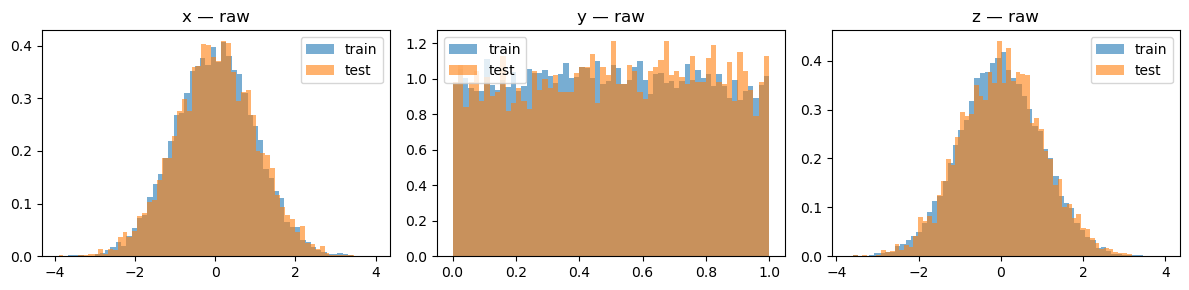

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, col in zip(axes, train.columns):
    ax.hist(train[col], bins=60, alpha=0.6, label='train', density=True)
    ax.hist(test[col],  bins=60, alpha=0.6, label='test',  density=True)
    ax.set_title(f'{col} — raw')
    ax.legend()
fig.tight_layout()


## 2. Step 1 — uniformize

Fit one ECDF per column on the train, then apply it to both train and test.

In [4]:
uniformizers = {col: fit_uniformize(train[col]) for col in train.columns}

train_u = pd.DataFrame({col: uniformizers[col](train[col]) for col in train.columns})
test_u  = pd.DataFrame({col: uniformizers[col](test[col])  for col in test.columns})


KS vs Uniform(0,1) — test sample:
  x: stat=0.0162  p=0.145
  y: stat=0.0226  p=0.012
  z: stat=0.0264  p=0.002


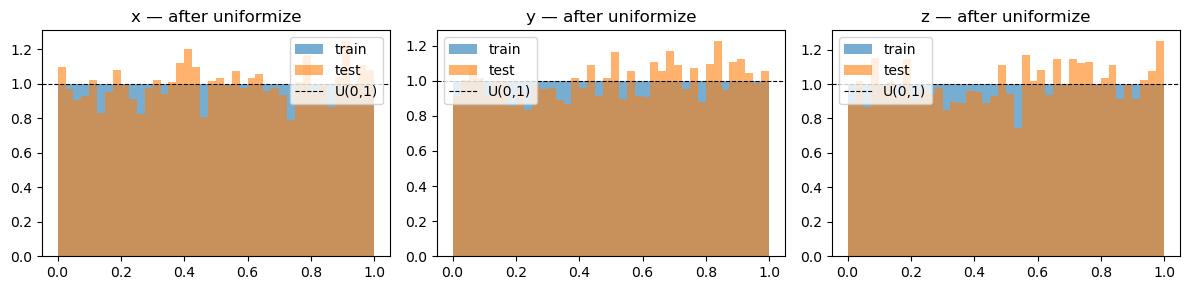

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, col in zip(axes, train_u.columns):
    ax.hist(train_u[col], bins=40, alpha=0.6, label='train', density=True)
    ax.hist(test_u[col],  bins=40, alpha=0.6, label='test',  density=True)
    ax.axhline(1.0, color='k', lw=0.8, ls='--', label='U(0,1)')
    ax.set_title(f'{col} — after uniformize')
    ax.legend()
fig.tight_layout()

print('KS vs Uniform(0,1) — test sample:')
for col in test_u.columns:
    stat, p = kstest(test_u[col], 'uniform')
    print(f'  {col}: stat={stat:.4f}  p={p:.3f}')


## 3. Step 2 — to_normal

Apply the probit transform. Each column should now be ≈ N(0, 1) on both samples.

In [6]:
train_z = pd.DataFrame({col: to_normal(train_u[col]) for col in train_u.columns})
test_z  = pd.DataFrame({col: to_normal(test_u[col])  for col in test_u.columns})

print('test_z mean / std per column:')
print(pd.DataFrame({'mean': test_z.mean(), 'std': test_z.std()}).round(3))


test_z mean / std per column:
    mean    std
x  0.022  1.010
y  0.035  1.002
z  0.035  1.007


KS vs N(0,1) — test sample:
  x: stat=0.0162  p=0.145
  y: stat=0.0226  p=0.012
  z: stat=0.0264  p=0.002


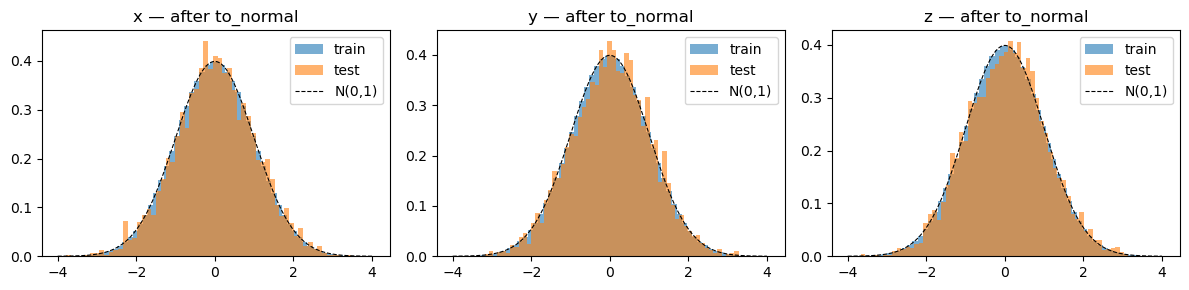

In [7]:
grid = np.linspace(-4, 4, 200)
pdf  = norm.pdf(grid)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, col in zip(axes, train_z.columns):
    ax.hist(train_z[col], bins=60, alpha=0.6, label='train', density=True)
    ax.hist(test_z[col],  bins=60, alpha=0.6, label='test',  density=True)
    ax.plot(grid, pdf, 'k--', lw=0.8, label='N(0,1)')
    ax.set_title(f'{col} — after to_normal')
    ax.legend()
fig.tight_layout()

print('KS vs N(0,1) — test sample:')
for col in test_z.columns:
    stat, p = kstest(test_z[col], 'norm')
    print(f'  {col}: stat={stat:.4f}  p={p:.3f}')


## 4. Correlation survives the transform

Marginals are now normal, but the variables are still correlated — that is what step 3 (PCA on the rotated, whitened space) will address.

In [8]:
print('train_z correlation:')
print(train_z.corr().round(2))
print()
print('test_z correlation:')
print(test_z.corr().round(2))


train_z correlation:
     x     y     z
x  1.0  0.50  0.50
y  0.5  1.00  0.49
z  0.5  0.49  1.00

test_z correlation:
     x    y    z
x  1.0  0.5  0.5
y  0.5  1.0  0.5
z  0.5  0.5  1.0
